# 🎬 Análisis Exploratorio de Datos — Netflix Titles

**Objetivo:** Explorar el catálogo de Netflix para identificar patrones y tendencias en el contenido disponible.

**Dataset:** [Netflix Movies and TV Shows](https://www.kaggle.com/datasets/shivamb/netflix-shows) — Kaggle

---

## 📦 1. Importación de Librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configuración visual global
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


## 📂 2. Carga del Dataset

> **Instrucción:** Descarga el archivo `netflix_titles.csv` desde [Kaggle](https://www.kaggle.com/datasets/shivamb/netflix-shows) y colócalo en la carpeta `../data/`

In [2]:
# Carga del dataset
df = pd.read_csv('../data/netflix_titles.csv')

print(f'📊 Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

📊 Dimensiones del dataset: 8807 filas × 12 columnas


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 🔍 3. Exploración Inicial

In [3]:
# Información general del dataset
print('=== TIPOS DE DATOS ===')
print(df.dtypes)
print()
print('=== VALORES NULOS POR COLUMNA ===')
nulls = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(2)
null_df = pd.DataFrame({'Nulos': nulls, 'Porcentaje (%)': null_pct})
print(null_df[null_df['Nulos'] > 0])

=== TIPOS DE DATOS ===
show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

=== VALORES NULOS POR COLUMNA ===
            Nulos  Porcentaje (%)
director     2634           29.91
cast          825            9.37
country       831            9.44
date_added     10            0.11
rating          4            0.05
duration        3            0.03


In [4]:
# Estadísticas descriptivas básicas
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


## 🧹 4. Limpieza de Datos

In [5]:
# Convertir 'date_added' a formato fecha
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')

# Extraer año y mes de adición
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

# Limpiar columna 'duration'
# Películas → duración en minutos
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)

# Tomar solo el primer país listado
df['country_main'] = df['country'].str.split(',').str[0].str.strip()

print('✅ Limpieza completada')
df[['title', 'type', 'date_added', 'year_added', 'duration', 'duration_int', 'country_main']].head()

✅ Limpieza completada


,title,type,date_added,year_added,duration,duration_int,country_main
0,Dick Johnson Is Dead,Movie,2021-09-25,2021.0,90 min,90.0,United States
1,Blood & Water,TV Show,2021-09-24,2021.0,2 Seasons,2.0,South Africa
2,Ganglands,TV Show,2021-09-24,2021.0,1 Season,1.0,NaN
3,Jailbirds New Orleans,TV Show,2021-09-24,2021.0,1 Season,1.0,NaN
4,Kota Factory,TV Show,2021-09-24,2021.0,2 Seasons,2.0,India


---
## 📊 5. Análisis y Visualizaciones

### ❓ Pregunta 1: ¿Películas o Series — cuál domina el catálogo?

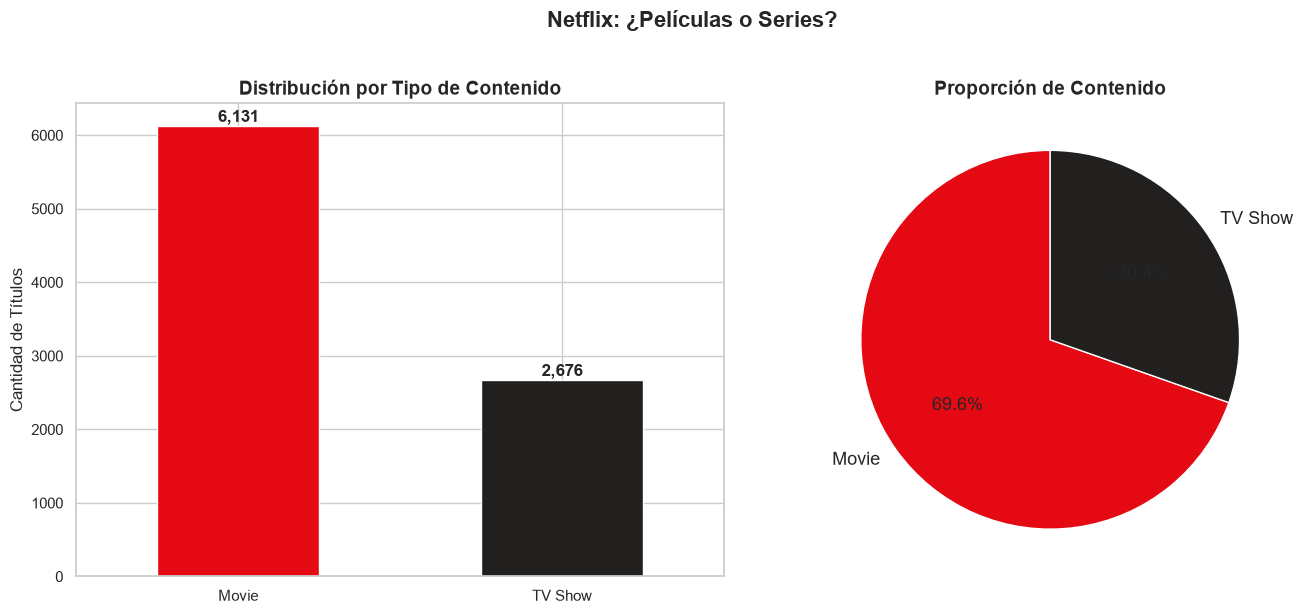


📌 Insight: Las películas representan el 69.6% del catálogo de Netflix.


In [6]:
type_counts = df['type'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras
colors = ['#E50914', '#221F1F']  # Colores Netflix
type_counts.plot(kind='bar', ax=ax1, color=colors, edgecolor='white', width=0.5)
ax1.set_title('Distribución por Tipo de Contenido', fontsize=14, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Cantidad de Títulos')
ax1.tick_params(axis='x', rotation=0)
for bar in ax1.patches:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{int(bar.get_height()):,}', ha='center', fontweight='bold')

# Gráfico de pie
ax2.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90,
        textprops={'fontsize': 13})
ax2.set_title('Proporción de Contenido', fontsize=14, fontweight='bold')

plt.suptitle('Netflix: ¿Películas o Series?', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/01_tipo_contenido.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📌 Insight: Las películas representan el {type_counts["Movie"]/len(df)*100:.1f}% del catálogo de Netflix.')

### ❓ Pregunta 2: ¿En qué años Netflix agregó más contenido?

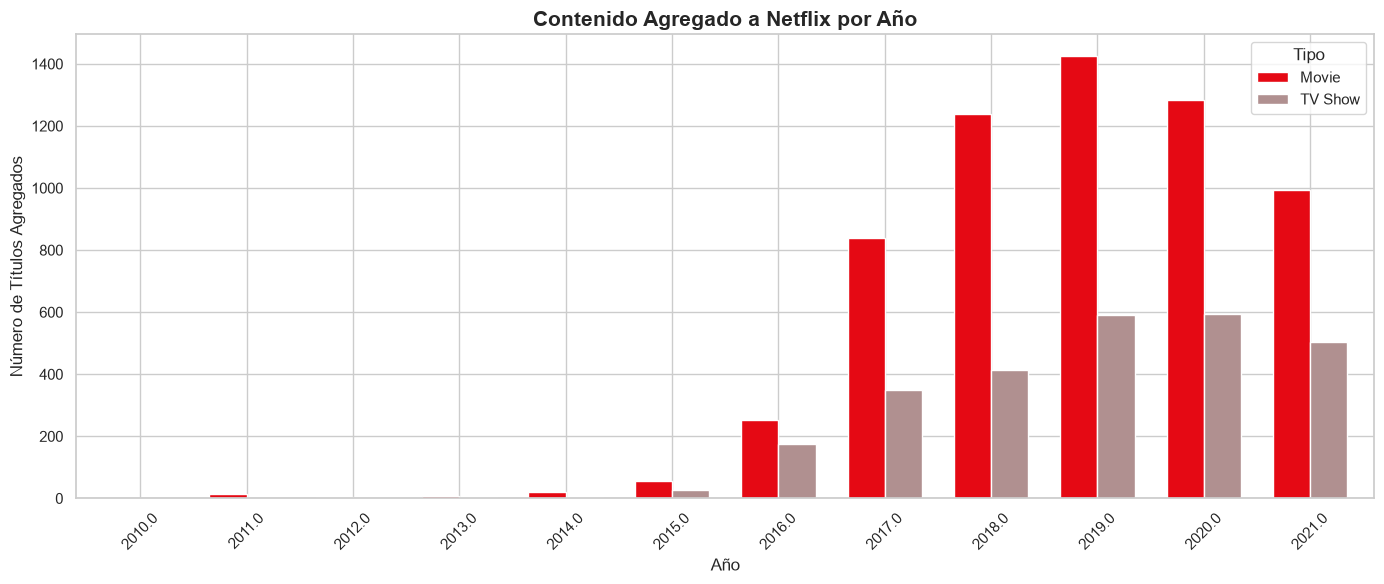


📌 Insight: El año con más adiciones de contenido fue 2019.


In [7]:
yearly = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
yearly = yearly[yearly.index >= 2010]  # Filtrar desde 2010

ax = yearly.plot(kind='bar', figsize=(14, 6),
                 color=['#E50914', '#B09090'],
                 edgecolor='white', width=0.7)

ax.set_title('Contenido Agregado a Netflix por Año', fontsize=15, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Número de Títulos Agregados')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Tipo')

plt.tight_layout()
plt.savefig('../images/02_contenido_por_anio.png', dpi=150, bbox_inches='tight')
plt.show()

peak_year = yearly.sum(axis=1).idxmax()
print(f'\n📌 Insight: El año con más adiciones de contenido fue {int(peak_year)}.')

### ❓ Pregunta 3: ¿Qué países producen más contenido en Netflix?

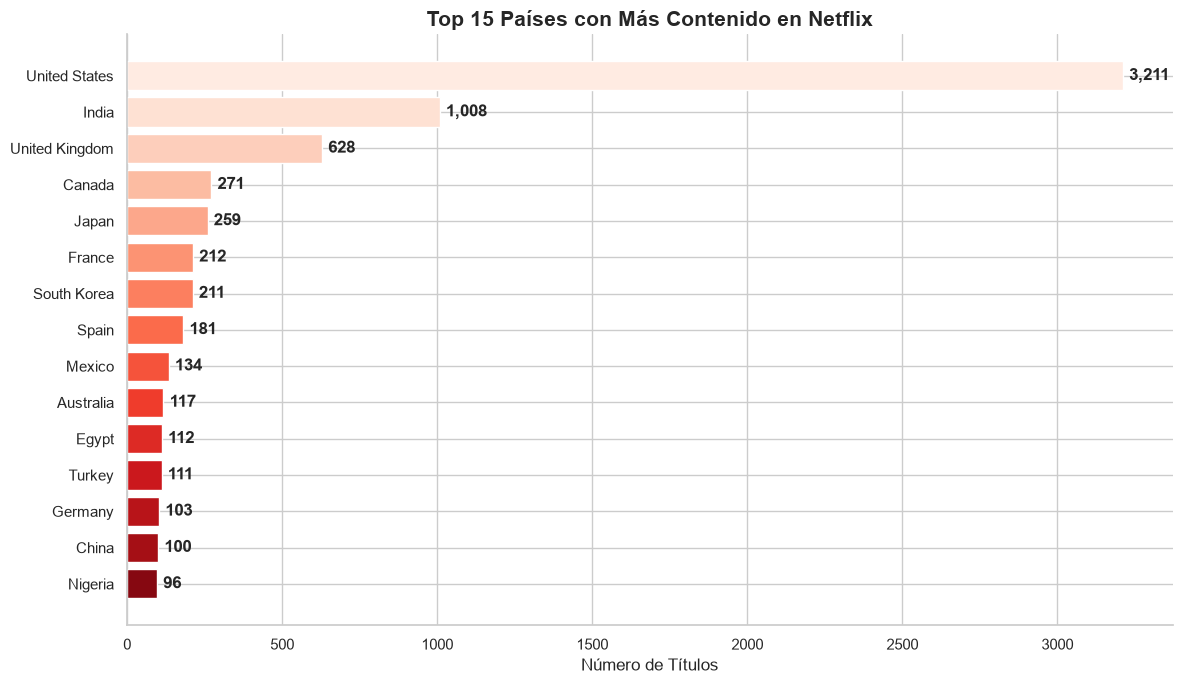


📌 Insight: United States lidera con 3,211 títulos, seguido de India con 1,008.


In [8]:
top_countries = (df['country_main']
                 .dropna()
                 .value_counts()
                 .head(15))

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1],
               color=sns.color_palette('Reds_r', 15))

for bar in bars:
    width = bar.get_width()
    ax.text(width + 20, bar.get_y() + bar.get_height()/2,
            f'{int(width):,}', va='center', fontweight='bold')

ax.set_title('Top 15 Países con Más Contenido en Netflix', fontsize=15, fontweight='bold')
ax.set_xlabel('Número de Títulos')
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../images/03_top_paises.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📌 Insight: {top_countries.index[0]} lidera con {top_countries.values[0]:,} títulos, '
      f'seguido de {top_countries.index[1]} con {top_countries.values[1]:,}.')

### ❓ Pregunta 4: ¿Cuáles son los géneros más populares?

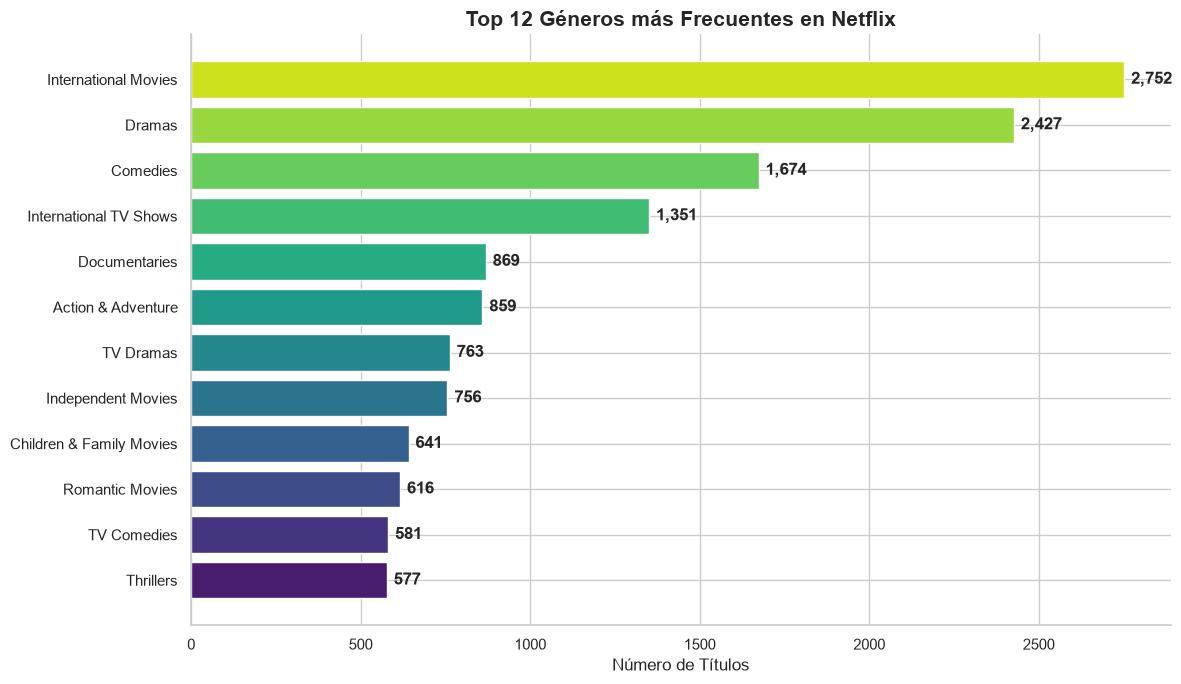


📌 Insight: El género más frecuente es "International Movies" con 2,752 títulos.


In [9]:
# Explotar géneros (cada fila puede tener múltiples separados por coma)
genres = (df['listed_in']
          .dropna()
          .str.split(',')
          .explode()
          .str.strip()
          .value_counts()
          .head(12))

fig, ax = plt.subplots(figsize=(12, 7))

palette = sns.color_palette('viridis', len(genres))
bars = ax.barh(genres.index[::-1], genres.values[::-1], color=palette)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 20, bar.get_y() + bar.get_height()/2,
            f'{int(width):,}', va='center', fontweight='bold')

ax.set_title('Top 12 Géneros más Frecuentes en Netflix', fontsize=15, fontweight='bold')
ax.set_xlabel('Número de Títulos')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../images/04_top_generos.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📌 Insight: El género más frecuente es "{genres.index[0]}" con {genres.values[0]:,} títulos.')

### ❓ Pregunta 5: ¿Cuánto duran las películas? (Distribución)

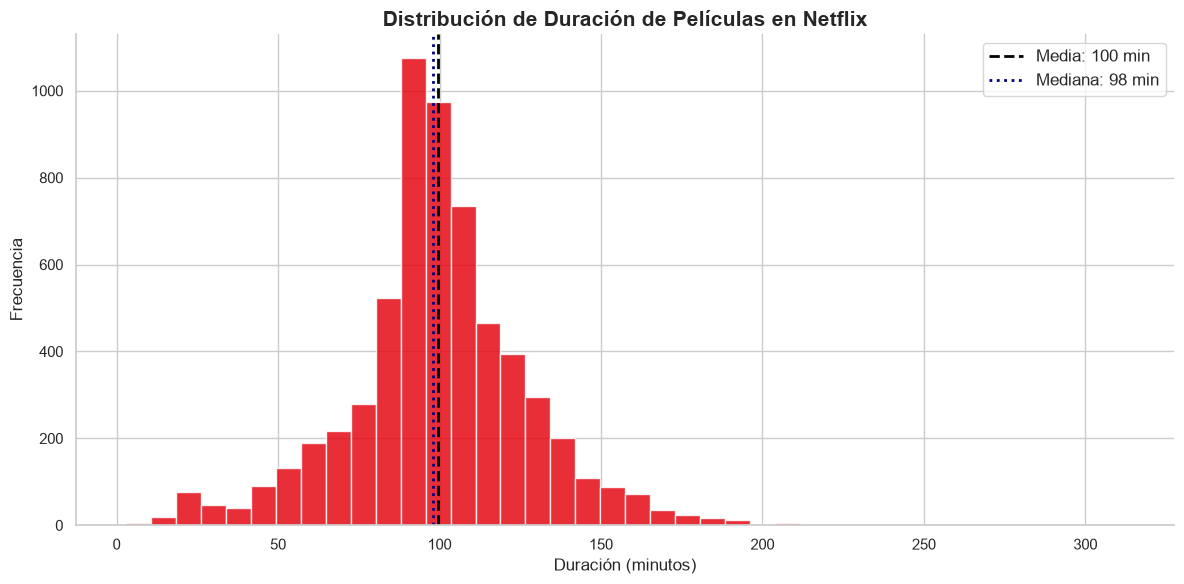


📌 Insight: La duración promedio de películas es 100 minutos, con una mediana de 98 minutos.


In [10]:
movies = df[df['type'] == 'Movie']['duration_int'].dropna()

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(movies, bins=40, color='#E50914', edgecolor='white', alpha=0.85)

mean_dur = movies.mean()
median_dur = movies.median()

ax.axvline(mean_dur, color='black', linestyle='--', linewidth=2,
           label=f'Media: {mean_dur:.0f} min')
ax.axvline(median_dur, color='navy', linestyle=':', linewidth=2,
           label=f'Mediana: {median_dur:.0f} min')

ax.set_title('Distribución de Duración de Películas en Netflix', fontsize=15, fontweight='bold')
ax.set_xlabel('Duración (minutos)')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../images/05_duracion_peliculas.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📌 Insight: La duración promedio de películas es {mean_dur:.0f} minutos, '
      f'con una mediana de {median_dur:.0f} minutos.')

### ❓ Pregunta 6: ¿Cómo ha evolucionado el contenido a lo largo del tiempo?

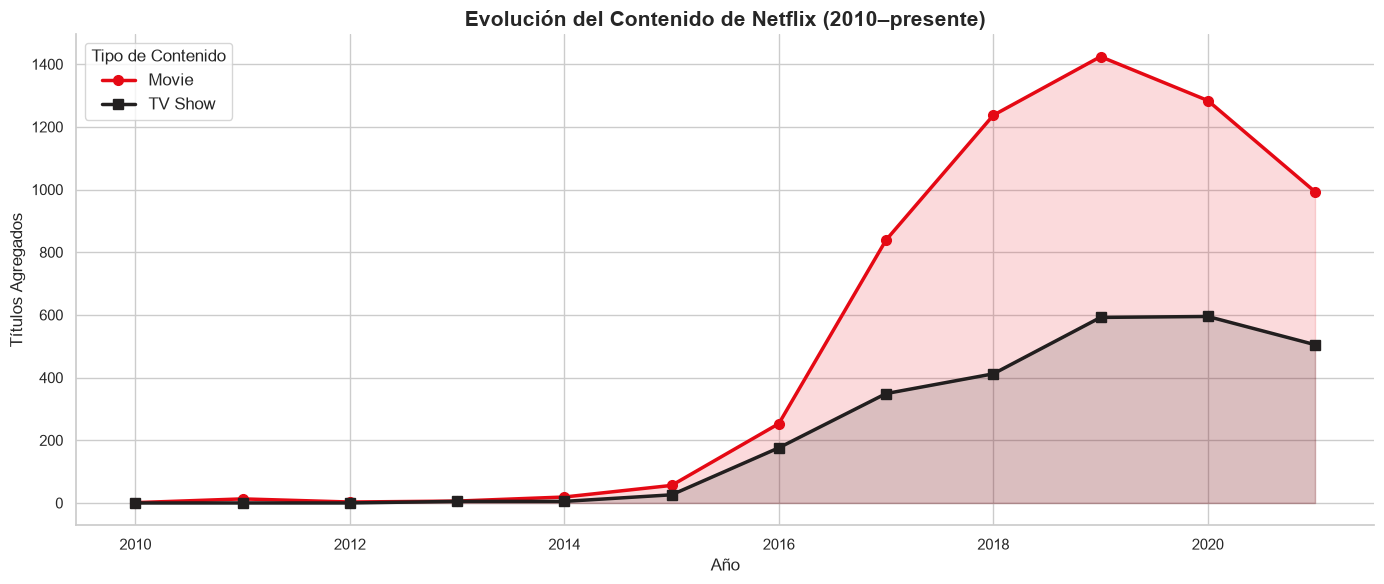


📌 Insight: Observamos el crecimiento acelerado de Netflix entre 2016 y 2019, con una caída notable durante la pandemia (2020–2021).


In [11]:
trend = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
trend = trend[trend.index >= 2010]

fig, ax = plt.subplots(figsize=(14, 6))

for col, color, marker in zip(trend.columns, ['#E50914', '#221F1F'], ['o', 's']):
    ax.plot(trend.index, trend[col], color=color, marker=marker,
            linewidth=2.5, markersize=7, label=col)

ax.fill_between(trend.index, trend.get('Movie', 0), alpha=0.15, color='#E50914')
ax.fill_between(trend.index, trend.get('TV Show', 0), alpha=0.15, color='#221F1F')

ax.set_title('Evolución del Contenido de Netflix (2010–presente)', fontsize=15, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Títulos Agregados')
ax.legend(title='Tipo de Contenido', fontsize=12)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../images/06_evolucion_contenido.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 Insight: Observamos el crecimiento acelerado de Netflix entre 2016 y 2019, '
      'con una caída notable durante la pandemia (2020–2021).')

---
## 📝 6. Resumen de Hallazgos

| # | Pregunta | Hallazgo |
|---|---|---|
| 1 | ¿Películas o Series? | Las películas dominan con ~70% del catálogo |
| 2 | ¿Año con más adiciones? | El pico fue en 2019 |
| 3 | ¿País con más contenido? | Estados Unidos lidera ampliamente |
| 4 | ¿Género más popular? | International Movies / Dramas |
| 5 | ¿Duración promedio? | ~100 minutos por película |
| 6 | ¿Tendencia temporal? | Crecimiento acelerado 2016–2019, luego desaceleración |

> **Nota:** Actualiza esta tabla con los valores exactos obtenidos en tu ejecución.

---

## ✅ Conclusiones

1. **El catálogo de Netflix es predominantemente de películas**, representando cerca del 70% del contenido total disponible.
2. **El crecimiento más agresivo ocurrió entre 2016 y 2019**, coincidiendo con la expansión global de la plataforma.
3. **Estados Unidos es el principal productor de contenido** en la plataforma, seguido de India y Reino Unido.
4. **El contenido internacional y los dramas son los géneros dominantes**, reflejando la estrategia de Netflix de atraer audiencias globales.
5. **Las películas tienen una duración promedio de ~100 minutos**, con una distribución aproximadamente normal.

---
*Análisis realizado por: **Camilo Sanchez Vasquez** | Proyecto de Portfolio — Analista de Datos*